In [1]:
print("hi")

hi


In [2]:
# Importing libraries
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

In [3]:
# defining device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [13]:
# Image Transform
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [14]:
# Dataset Load
train_dir = "../data/train"
test_dir = "../data/test"

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

print("ClassesForTraining:", train_dataset.classes)
print("ClassesForTesting:", test_dataset.classes)

ClassesForTraining: ['Acne and Rosacea Photos', 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions', 'Atopic Dermatitis Photos', 'Bullous Disease Photos', 'Cellulitis Impetigo and other Bacterial Infections', 'Eczema Photos']
ClassesForTesting: ['Acne and Rosacea Photos', 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions', 'Atopic Dermatitis Photos', 'Bullous Disease Photos', 'Cellulitis Impetigo and other Bacterial Infections', 'Eczema Photos']


In [7]:
# Dataloader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [32]:
# Model Setup
from torchvision import models
import torch.nn as nn

model = models.resnet50(pretrained=True)

# for param in model.parameters():
#     param.requires_grad = False  # freeze backbone

# # ✅ UNFREEZE last block (REQUIRED for Grad-CAM)
# for param in model.layer4.parameters():
#     param.requires_grad = True

for param in model.parameters():
    param.requires_grad = False

# Unfreeze last TWO blocks
for param in model.layer3.parameters():
    param.requires_grad = True

for param in model.layer4.parameters():
    param.requires_grad = True

num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, len(train_dataset.classes))
)

model = model.to(device)

In [33]:
# Loss + Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [17]:
# TRAINING LOOP (FIXED VERSION)
# This is your corrected loop with debugging + speed awareness:

epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss:.4f}")

Epoch [1/10], Loss: 200.2925
Epoch [2/10], Loss: 181.3714
Epoch [3/10], Loss: 173.3984
Epoch [4/10], Loss: 170.0252
Epoch [5/10], Loss: 162.8924
Epoch [6/10], Loss: 158.3111
Epoch [7/10], Loss: 156.6082
Epoch [8/10], Loss: 156.6336
Epoch [9/10], Loss: 152.3636
Epoch [10/10], Loss: 153.0756


In [34]:
# CAM Extraction
from torchcam.methods import GradCAM
from torchvision.transforms.functional import to_pil_image

cam_extractor = GradCAM(model, target_layer="layer4")

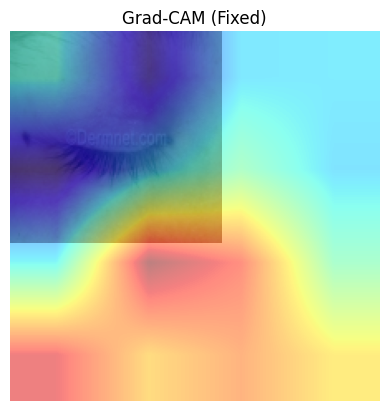

In [31]:
# Testing CAM on a sample image
from torchcam.methods import GradCAM
import matplotlib.pyplot as plt
import torch.nn.functional as F

model.eval()

cam_extractor = GradCAM(model, target_layer="layer4")

images, labels = next(iter(test_loader))
images = images.to(device)

# Forward pass (NO torch.no_grad)
outputs = model(images)
pred_class = outputs.argmax(dim=1)

# Get CAM
activation_map = cam_extractor(pred_class[0].item(), outputs)[0]

# ✅ Resize heatmap to match image size
# activation_map shape: [C, H, W]
heatmap = activation_map.mean(dim=0)  # ✅ make it [H, W]

# Add batch + channel dims → [1,1,H,W]
heatmap = heatmap.unsqueeze(0).unsqueeze(0)

# Resize
heatmap = F.interpolate(heatmap, size=(224, 224), mode='bilinear', align_corners=False)

# Remove extra dims
heatmap = heatmap.squeeze().cpu()

# Normalize (important)
heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())
# Prepare image
img = images[0].cpu().permute(1, 2, 0)

# Plot
plt.imshow(img)
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.title("Grad-CAM (Fixed)")
plt.axis('off')
plt.show()

In [35]:
# model evaluation
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

RuntimeError: cannot register a hook on a tensor that doesn't require gradient

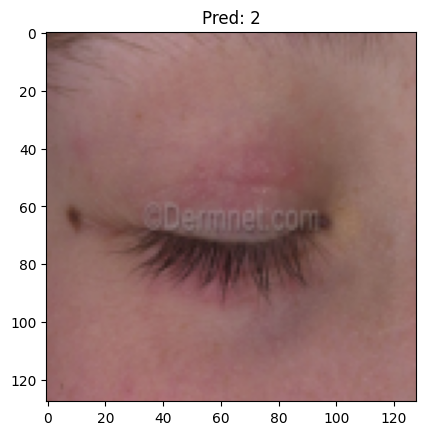

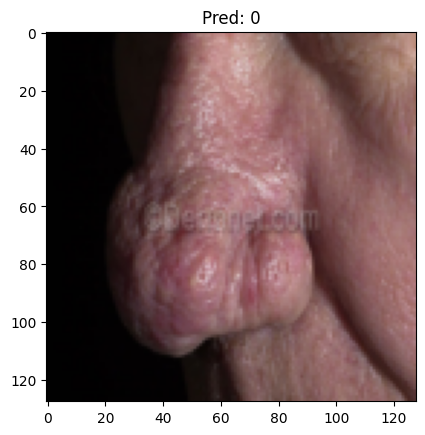

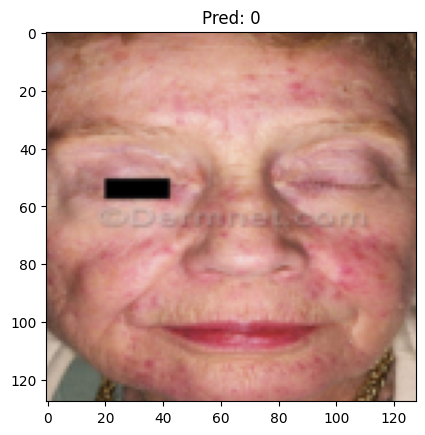

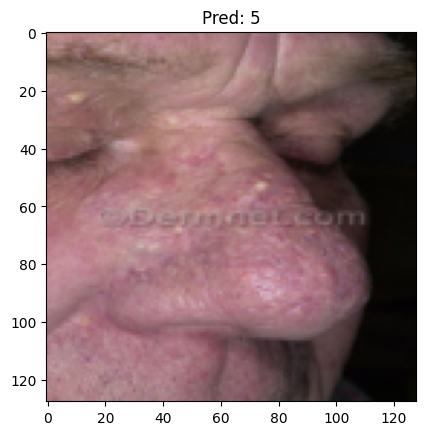

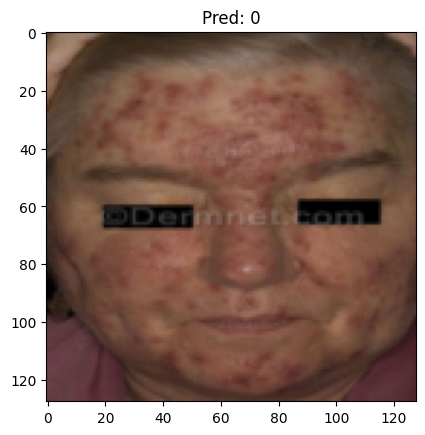

In [12]:
# Visualize some predictions
import matplotlib.pyplot as plt

images, labels = next(iter(test_loader))
images = images.to(device)

outputs = model(images)
_, preds = torch.max(outputs, 1)

images = images.cpu()

for i in range(5):
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title(f"Pred: {preds[i].item()}")
    plt.show()